<a href="https://colab.research.google.com/github/aishruban5566-ctrl/mlt-programs/blob/main/task11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

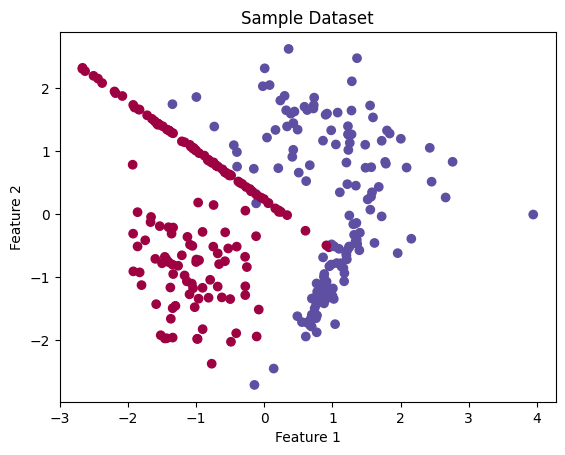

Classification Rate: 0.95
Accuracy: 0.95
Precision: 0.9655172413793104
Recall: 0.9333333333333333

Confusion Matrix:
 [[29  1]
 [ 2 28]]


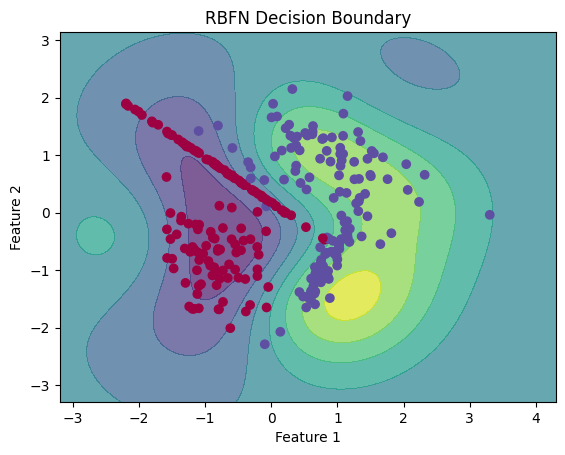

In [1]:
# Task 11 - Radial Basis Function Network Classification
# Run this entire code in Google Colab

# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import cdist


# Step 2: Generate Sample Dataset
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_classes=2,
    n_clusters_per_class=2,
    n_redundant=0,
    random_state=42
)

# Visualize dataset
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral)
plt.title("Sample Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# Step 3: Preprocess Data (Standardization)
scaler = StandardScaler()
X = scaler.fit_transform(X)


# Step 4: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Step 5: Define Gaussian Radial Basis Function
def gaussian_rbf(x, center, sigma):
    return np.exp(-cdist(x, center, 'sqeuclidean') / (2 * sigma**2))


# Step 6: Choose RBF Centers
n_centers = 10
center_indices = np.random.choice(X_train.shape[0], n_centers, replace=False)
rbf_centers = X_train[center_indices]

rbf_width = 1.0


# Step 7: RBF Layer
def rbf_layer(X, centers, width):
    return gaussian_rbf(X, centers, width)


# Step 8: Train Model
rbf_outputs_train = rbf_layer(X_train, rbf_centers, rbf_width)

lr = LinearRegression()
lr.fit(rbf_outputs_train, y_train)


# Step 9: Test Model
rbf_outputs_test = rbf_layer(X_test, rbf_centers, rbf_width)

y_pred = lr.predict(rbf_outputs_test)

# Convert to binary classification
y_pred_class = (y_pred >= 0.5).astype(int)


# Step 10: Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred_class)
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)

classification_rate = accuracy   # same as accuracy


print("Classification Rate:", classification_rate)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)


# Step 11: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)
print("\nConfusion Matrix:\n", cm)


# Step 12: Decision Boundary Visualization

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

grid = np.c_[xx.ravel(), yy.ravel()]

rbf_outputs_grid = rbf_layer(grid, rbf_centers, rbf_width)
Z = lr.predict(rbf_outputs_grid)

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.7)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral)

plt.title("RBFN Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()